In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print("✅ Ready.")

PyTorch: 2.12.0
✅ Ready.


In [2]:
# Load the same synthetic dataset we used before
df = pd.read_csv('../data/processed/creditcard_processed.csv')

# Use only LEGITIMATE transactions for training
# Autoencoder learns what "normal" looks like
# It will fail to reconstruct fraud — that failure IS the fraud signal

legit = df[df['Class'] == 0].drop('Class', axis=1)
fraud = df[df['Class'] == 1].drop('Class', axis=1)

print(f"Legitimate transactions: {len(legit)}")
print(f"Fraud transactions: {len(fraud)}")

# Scale features
scaler = StandardScaler()
X_legit = scaler.fit_transform(legit).astype(np.float32)
X_fraud  = scaler.transform(fraud).astype(np.float32)

print(f"\nFeature shape: {X_legit.shape[1]}")
print("✅ Data ready.")

Legitimate transactions: 284315
Fraud transactions: 492

Feature shape: 30
✅ Data ready.


In [3]:
from sklearn.model_selection import train_test_split

# Split legit into train and test
X_train, X_test_legit = train_test_split(X_legit, test_size=0.2, random_state=42)

# Test set = legit + fraud combined (for evaluation)
X_test  = np.vstack([X_test_legit, X_fraud])
y_test  = np.array([0] * len(X_test_legit) + [1] * len(X_fraud))

print(f"Train (legit only): {X_train.shape}")
print(f"Test (legit + fraud): {X_test.shape}")
print(f"Test fraud rate: {y_test.mean()*100:.2f}%")
print("✅ Split ready.")

Train (legit only): (227452, 30)
Test (legit + fraud): (57355, 30)
Test fraud rate: 0.86%
✅ Split ready.


In [4]:
class LegitDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

train_dataset = LegitDataset(X_train)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"Train batches: {len(train_loader)}")
print("✅ DataLoader ready.")

Train batches: 889
✅ DataLoader ready.


In [5]:
class FraudAutoencoder(nn.Module):
    """
    Encoder compresses input to a small bottleneck.
    Decoder reconstructs the original from the bottleneck.
    Trained only on legitimate transactions.
    Fraud transactions have high reconstruction error — that's the signal.
    """
    def __init__(self, input_dim):
        super().__init__()

        # Encoder — compress
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)   # bottleneck — 8 dimensions
        )

        # Decoder — reconstruct
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded  = self.encoder(x)
        decoded  = self.decoder(encoded)
        return decoded

    def reconstruction_error(self, x):
        with torch.no_grad():
            reconstructed = self.forward(x)
            error = torch.mean((x - reconstructed) ** 2, dim=1)
        return error


INPUT_DIM = X_train.shape[1]
model = FraudAutoencoder(INPUT_DIM)

total_params = sum(p.numel() for p in model.parameters())
print(f"Input dimensions: {INPUT_DIM}")
print(f"Bottleneck: 8 dimensions")
print(f"Total parameters: {total_params:,}")
print(f"\nArchitecture:\n{model}")
print("✅ Autoencoder ready.")

Input dimensions: 30
Bottleneck: 8 dimensions
Total parameters: 9,478

Architecture:
FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=32, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=30, bias=True)
  )
)
✅ Autoencoder ready.


In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

EPOCHS = 50
train_losses = []
best_loss = float('inf')
best_state = None

print("Training Autoencoder...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = model.state_dict().copy()
        flag = " ← best"
    else:
        flag = ""

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.6f}{flag}")

model.load_state_dict(best_state)
print(f"\n✅ Training complete. Best loss: {best_loss:.6f}")

Training Autoencoder...

Epoch 05/50 | Loss: 0.591797 ← best
Epoch 10/50 | Loss: 0.552860 ← best
Epoch 15/50 | Loss: 0.539297 ← best
Epoch 20/50 | Loss: 0.536383
Epoch 25/50 | Loss: 0.529686 ← best
Epoch 30/50 | Loss: 0.523794 ← best
Epoch 35/50 | Loss: 0.520083 ← best
Epoch 40/50 | Loss: 0.519301
Epoch 45/50 | Loss: 0.513122 ← best
Epoch 50/50 | Loss: 0.510976

✅ Training complete. Best loss: 0.508522


Legit reconstruction error  — mean: 0.4079, std: 0.8870
Fraud reconstruction error  — mean: 21.1714, std: 25.5393
Separation ratio: 51.90x

ROC-AUC: 0.9489
Optimal threshold: 1.0955

              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     56863
       Fraud       0.15      0.85      0.26       492

    accuracy                           0.96     57355
   macro avg       0.58      0.91      0.62     57355
weighted avg       0.99      0.96      0.97     57355



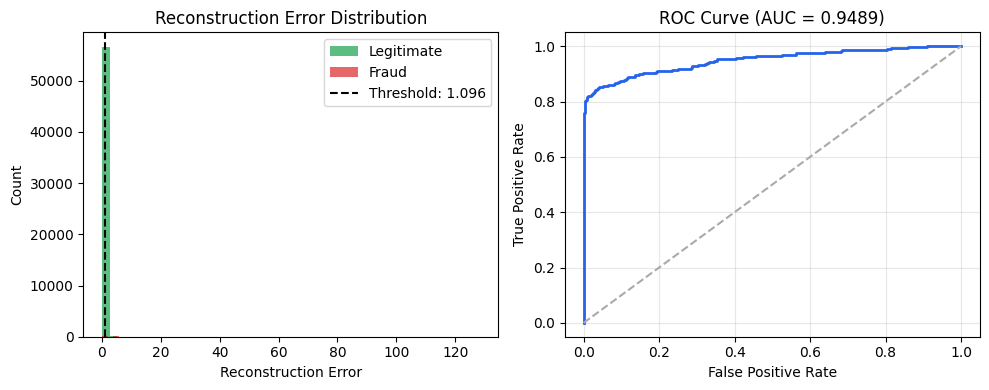

In [7]:
model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
errors = model.reconstruction_error(X_test_tensor).numpy()

# Reconstruction errors for legit vs fraud
legit_errors = errors[y_test == 0]
fraud_errors  = errors[y_test == 1]

print(f"Legit reconstruction error  — mean: {legit_errors.mean():.4f}, std: {legit_errors.std():.4f}")
print(f"Fraud reconstruction error  — mean: {fraud_errors.mean():.4f}, std: {fraud_errors.std():.4f}")
print(f"Separation ratio: {fraud_errors.mean() / legit_errors.mean():.2f}x")

# Find optimal threshold
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, errors)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
auc               = roc_auc_score(y_test, errors)

print(f"\nROC-AUC: {auc:.4f}")
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred = (errors >= optimal_threshold).astype(int)
print(f"\n{classification_report(y_test, y_pred, target_names=['Legit','Fraud'])}")

# Plot reconstruction error distributions
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(legit_errors, bins=50, alpha=0.7, color='#16a34a', label='Legitimate')
plt.hist(fraud_errors,  bins=50, alpha=0.7, color='#dc2626', label='Fraud')
plt.axvline(optimal_threshold, color='black', linestyle='--', label=f'Threshold: {optimal_threshold:.3f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='#2563eb', linewidth=2)
plt.plot([0,1],[0,1],'--', color='#aaa')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/autoencoder_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
import os
import joblib
os.makedirs('../artifacts', exist_ok=True)

# Save model
torch.save({
    'model_state_dict': best_state,
    'input_dim':        INPUT_DIM,
    'optimal_threshold': optimal_threshold,
    'auc':              auc,
    'best_loss':        best_loss
}, '../artifacts/autoencoder_model.pt')

# Save scaler
joblib.dump(scaler, '../artifacts/ae_scaler.pkl')

print("✅ Autoencoder saved to artifacts/autoencoder_model.pt")
print("✅ Scaler saved to artifacts/ae_scaler.pkl")
print(f"\nModel AUC: {auc:.4f}")
print(f"Threshold: {optimal_threshold:.4f}")
print(f"\nFiles in artifacts/:")
for f in sorted(os.listdir('../artifacts')):
    print(f"  - {f}")

✅ Autoencoder saved to artifacts/autoencoder_model.pt
✅ Scaler saved to artifacts/ae_scaler.pkl

Model AUC: 0.9489
Threshold: 1.0955

Files in artifacts/:
  - ae_scaler.pkl
  - autoencoder_evaluation.png
  - autoencoder_model.pt
  - confusion_matrix.png
  - feature_cols.json
  - feature_importance.png
  - fraud_model.pkl
  - gb_v2.pkl
  - iso_model.pkl
  - iso_v2.pkl
  - le_device.pkl
  - le_location.pkl
  - le_merchant.pkl
  - le_time.pkl
  - lr_model.pkl
  - lr_v2.pkl
  - lstm_confusion_matrix.png
  - lstm_model.pt
  - lstm_training_curves.png
  - model_metrics.json
  - rf_model.pkl
  - rf_v2.pkl
  - scaler.pkl
  - xgb_v2.pkl
